The purpose of this file is to analyze the .txt files exported by the ATEX software

I want to plot my data in a way that is comparable to how Ernould chapter 4 plots his database

Plots 

When disorientation angle is varied: 
- Fig 2a - Max and Min error of von mises strain versus disorientation 
- Fig 9a  - Max relative error versus disortination, plotted for each of the von mises strain values as a line plot 
- Fig 9c - Relative error versus disorientation for each of the components as a scatter plot 


When strain is varied: 
- Fig 2b - Max and Min error of disorientation angle versus strain 
- Fig 9b - see above 

###  Imports

In [1]:

import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import conversions
import os
import ErnouldsMethod
import utilities

from pc_homography_correction import (
    correct_scan_homographies,
    summarise_geometric_correction,
    fractional_to_h2f,
    plot_pc_correction_summary,
    plot_pc_geometry_steps,
)

Before you can read in the file make sure that the line DATA BEGIN is commented

# Inputs

In [2]:
#EMEBSD version 
#file that contains all of the deformation gradient data exported from Al_results visulalization
filename = '/Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/results/SiGe/SiGe_largerRegion_TesterRegion_April_7_2026_npyfiles/SiGe_largerRegion_TesterRegion_homographies_April_7_2026.npy'

#results folder path
foldername = f'/Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/results/SiGe/SiGe_PCcorrectionApplied_Apr8/'

# ---- Euler angle source ----
# Set ang_file to the path of a .ang file to read per-pattern Euler angles from it.
# Set to None to use the single euler_angles_deg value below for all patterns.
ang_file = '/Users/crestiennedechaine/OriginalData/Si_Ge_Dataset/DI_largerRegion/SiGe_largerRegion_selectedArea_20260322_512x512.ang'  # e.g. '/path/to/scan.ang'

# Single Euler angle (Bunge convention, degrees) — used only when ang_file is None
euler_angles_deg = np.array([10.00269719, 43.80376935, 347.2588334])  # [phi1, Phi, phi2] in degrees

#How many Rows and Columns were in the original EBSD scan?
Rows = 10 
Columns = 132  
patshape = np.array([512, 512]) #shape of the detector in pixels (height, width)

pixel_size = 30 #pixel size in microns

pattern_center_edax= np.array([0.6871, 0.8929, 0.67061]) #EDAX fractional coordinates (will be converted to bruker convention in the next line)

#---- Tilt for the rotation matrix, in degrees
SampleTilt = 70.0
DetectorTilt = 10.0 

samp_frame = True #whether to visualize in the sample reference frame (True) or EBSD reference frame (False)

# ---- PC correction parameters ----
# Reference pattern position in the scan grid (row, col).
# Must match x0 used in your runner script.
ref_position = (0, 0) #what was your reference position in the scan grid when you ran the DIC-HREBSD analysis? This should match the x0 variable in your runner script.
#apply PC correction to the homographies? (True/False)
apply_pc_correction = True #set to True to apply the PC correction to the homographies, False to visualize the uncorrected homographies

# Physical step size from the .ang file XSTEP header, in microns.
step_size_um = 2.6 # <-- update from your .ang file




#-------- Calculated parameters --------


pattern_center= np.array([0.6871, 1-0.8929, 1.06971]) #bruker convention for PC from upper left
homography_center = np.array([0.5, 0.5]) #homography center in fractional coordinates (x, y), typically (0.5, 0.5) for centred-pixel format
xo = np.array([(homography_center[0]-pattern_center[0])*patshape[0], (homography_center[1]-pattern_center[1])*patshape[1], (pattern_center[2]* patshape[1])]) #vector 

os.makedirs(foldername, exist_ok=True)




# Conversion to Homography to Strain

h shape: (10, 132, 8)
Applying projection centre drift correction...
Geometric (PC-induced) shape-function correction summary
  component           min           max         |max|
  h11       0.0000e+00    7.1259e-04    7.1259e-04
  h12       0.0000e+00    0.0000e+00    0.0000e+00
  h13      -1.1353e+01    6.8262e-02    1.1353e+01
  h21       0.0000e+00    0.0000e+00    0.0000e+00
  h22       0.0000e+00    7.1259e-04    7.1259e-04
  h23       0.0000e+00    6.0145e-01    6.0145e-01
  h31       0.0000e+00    0.0000e+00    0.0000e+00
  h32       0.0000e+00    0.0000e+00    0.0000e+00

  Corner values (h11, h13, h22, h23) [TL, TR, BL, BR]:
    TL: h11=0.0000e+00  h13=0.0000e+00  h22=0.0000e+00  h23=0.0000e+00
    TR: h11=0.0000e+00  h13=-1.1353e+01  h22=0.0000e+00  h23=0.0000e+00
    BL: h11=7.1259e-04  h13=6.8262e-02  h22=7.1259e-04  h23=6.0145e-01
    BR: h11=7.1259e-04  h13=-1.1293e+01  h22=7.1259e-04  h23=6.0145e-01
Saved /Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/results/

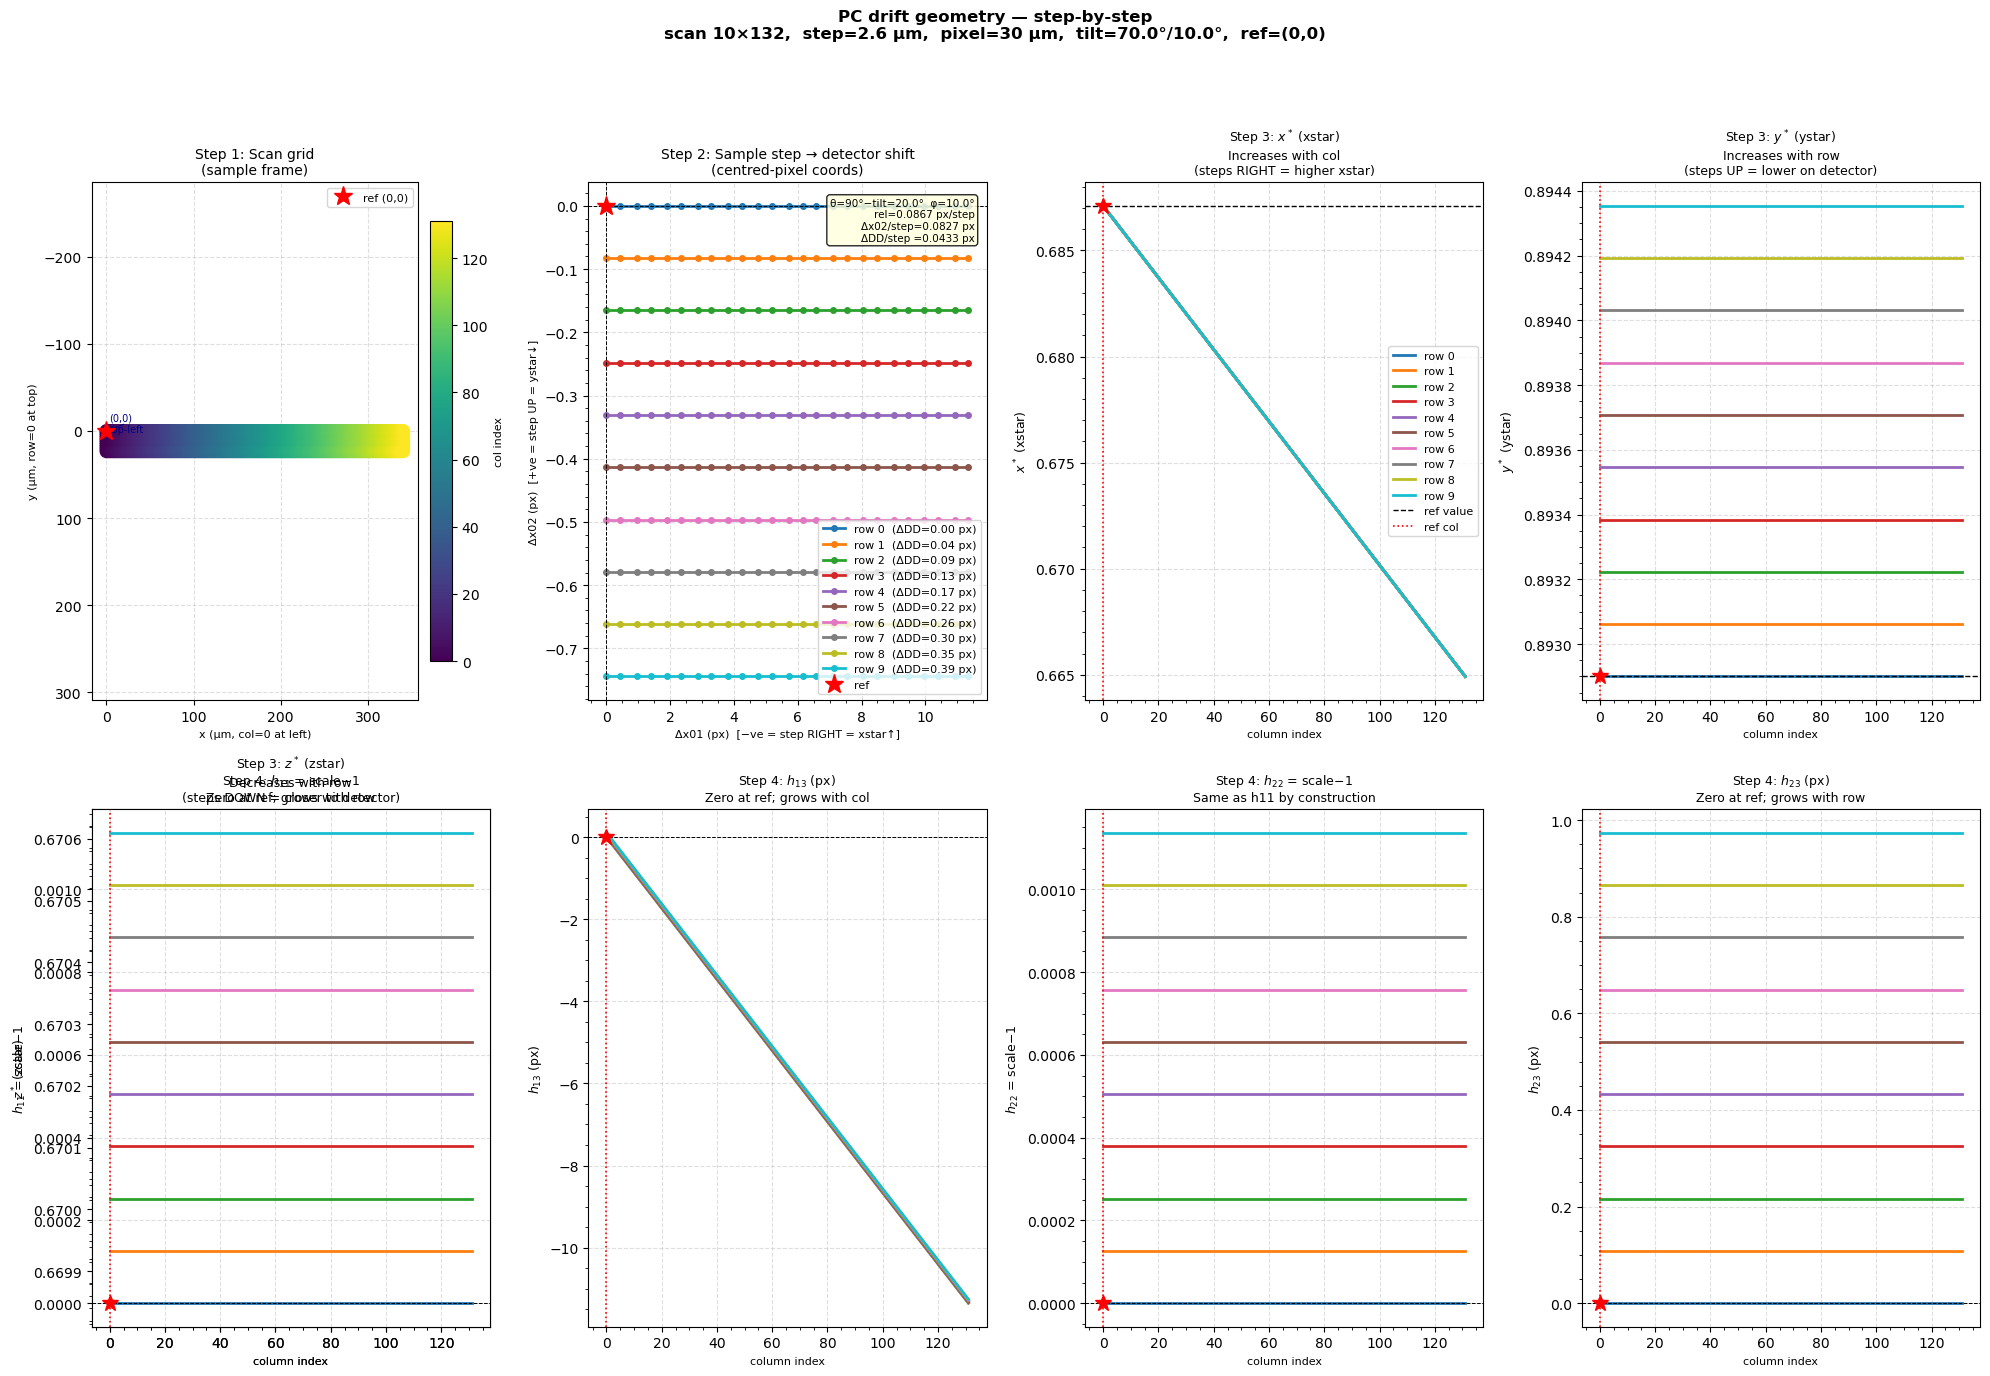

Saved /Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/results/SiGe/SiGe_PCcorrectionApplied_Apr8/PC_correction_summary.png


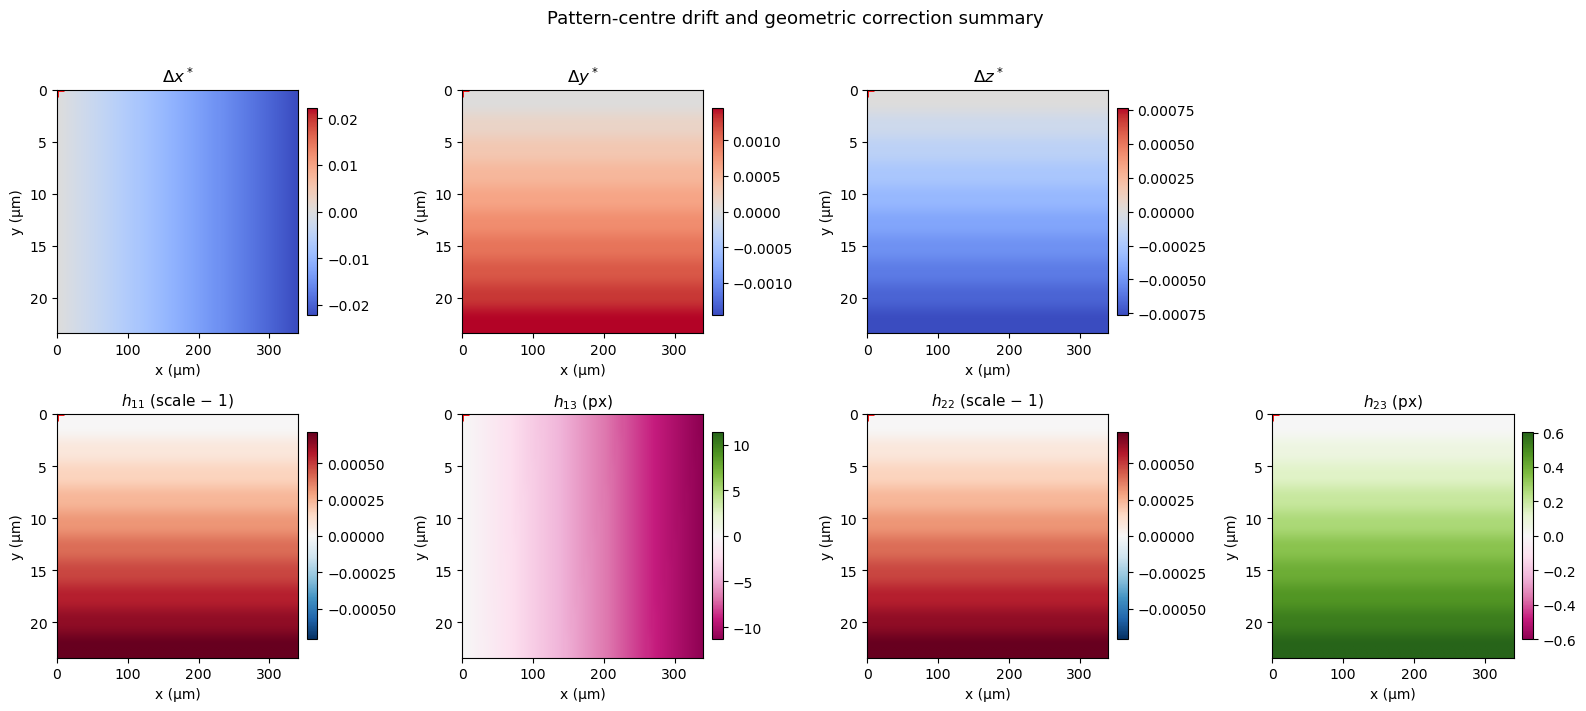

Per-position xo shape: (1320, 3)
(1320, 3, 3)


In [3]:
h = np.load(
        filename
    )

print("h shape:", h.shape)  # should be (N, 8) where N is the number of patterns

if h.shape[1] != 8:
    #assume h is in shape (Rows, Columns, 8) and reshape to (Rows*Columns, 8)
    h = h.reshape(Rows*Columns, 8)

#h is in column major order convert h to row major order for comparison
h11 = h[:, 0]
h12 = h[:, 1]
h13 = h[:, 2]
h21 = h[:, 3]
h22 = h[:, 4]
h23 = h[:, 5]
h31 = h[:, 6]
h32 = h[:, 7]

#restack h in row major order
h_calc = np.stack((h11, h12, h13, h21, h22, h23, h31, h32), axis=1)


# ── PC-drift correction ──────────────────────────────────────────────────
# The electron beam samples different points on the tilted sample as it
# steps across the scan.  This shifts the projection centre (PC) and
# produces a geometric component in every measured homography even with
# zero material deformation.  We remove that component here.

if apply_pc_correction:
    print("Applying projection centre drift correction...")

    h_calc_2d = h_calc.reshape(Rows, Columns, 8)
    h_corrected_2d, PC_grid_frac, PC_grid_h2f, TS_inv = correct_scan_homographies(
        H_measured        = h_calc_2d,
        PC_ref_frac       = pattern_center,      # (xstar, ystar, zstar) EDAX fractional
        ref_position      = ref_position,         # (row_ref, col_ref)
        scan_shape        = (Rows, Columns),
        step_size_um      = step_size_um,
        pixel_size_um     = pixel_size,
        patshape          = tuple(patshape),      # (height_px, width_px)
        sample_tilt_deg   = SampleTilt,
        detector_tilt_deg = DetectorTilt,
          # or 'matrix' for large corrections
    )

    summarise_geometric_correction(TS_inv, (Rows, Columns))

    plot_pc_geometry_steps(
        PC_ref_frac       = pattern_center_edax,
        ref_position      = ref_position,
        scan_shape        = (Rows, Columns),
        step_size_um      = step_size_um,
        pixel_size_um     = pixel_size,
        patshape          = tuple(patshape),
        sample_tilt_deg   = SampleTilt,
        detector_tilt_deg = DetectorTilt,
        save_path         = foldername + 'PC_geometry_steps.png',
    )

    plot_pc_correction_summary(
        PC_grid_frac = PC_grid_frac,
        TS_inv       = TS_inv,
        scan_shape   = (Rows, Columns),
        step_size_um = step_size_um,
        ref_position = ref_position,
        save_path    = foldername + 'PC_correction_summary.png',
    )

    # Use the PC-drift-corrected homographies AND the per-position PC in h2F.
    h_calc = h_corrected_2d.reshape(Rows * Columns, 8)
    xo = PC_grid_h2f.reshape(Rows * Columns, 3)
    print('Per-position xo shape:', xo.shape)

# If no PC correction, use the single reference PC for all patterns
if not apply_pc_correction:
    xo = fractional_to_h2f(pattern_center_edax, tuple(patshape))

F = conversions.h2F(h_calc, xo)

#pring F shape
print(F.shape)
epsilon, omega = conversions.F2strain(F)




In [4]:

R = utilities.rotation_matrix_passive(DetectorTilt, SampleTilt)
print("Rotation Matrix R:")
print(R)
print(R.T)

Rotation Matrix R:
[[ 0.         0.8660254 -0.5      ]
 [ 1.         0.         0.       ]
 [ 0.        -0.5       -0.8660254]]
[[ 0.         1.         0.       ]
 [ 0.8660254  0.        -0.5      ]
 [-0.5        0.        -0.8660254]]


In [5]:
if samp_frame:
    #need to rotate epsilon and omega by R.T (bc we need to go from detector to sample and R is the rotation from sample to detector) and R (bc we need to rotate the second index of epsilon and omega)
    for i in range(epsilon.shape[0]): 
        epsilon[i, :, :] = R @ epsilon[i,:,:] @ R.T
        omega[i,:, :] = R @ omega[i, :, :] @ R.T

This is the code to read in a .csv file generated by pyHREBSD

In [6]:

e11 = epsilon[:, 0, 0]
e12 = epsilon[:, 0, 1]
e13 = epsilon[:, 0, 2]
e22 = epsilon[:, 1, 1]
e23 = epsilon[:, 1, 2]
e33 = epsilon[:, 2, 2]
w13 = omega[:, 0, 2]
w21 = omega[:, 1, 0]
w32 = omega[:, 2, 1]

#convert the rotation components to degrees
w13 = np.degrees(w13)
w21 = np.degrees(w21)
w32 = np.degrees(w32)


In [7]:
#reshape all components to Rows x Columns
e11 = e11.reshape((Rows, Columns))
e12 = e12.reshape((Rows, Columns))
e13 = e13.reshape((Rows, Columns))
e22 = e22.reshape((Rows, Columns))
e23 = e23.reshape((Rows, Columns))
e33 = e33.reshape((Rows, Columns))
w13 = w13.reshape((Rows, Columns))
w21 = w21.reshape((Rows, Columns))
w32 = w32.reshape((Rows, Columns))


# Plotting

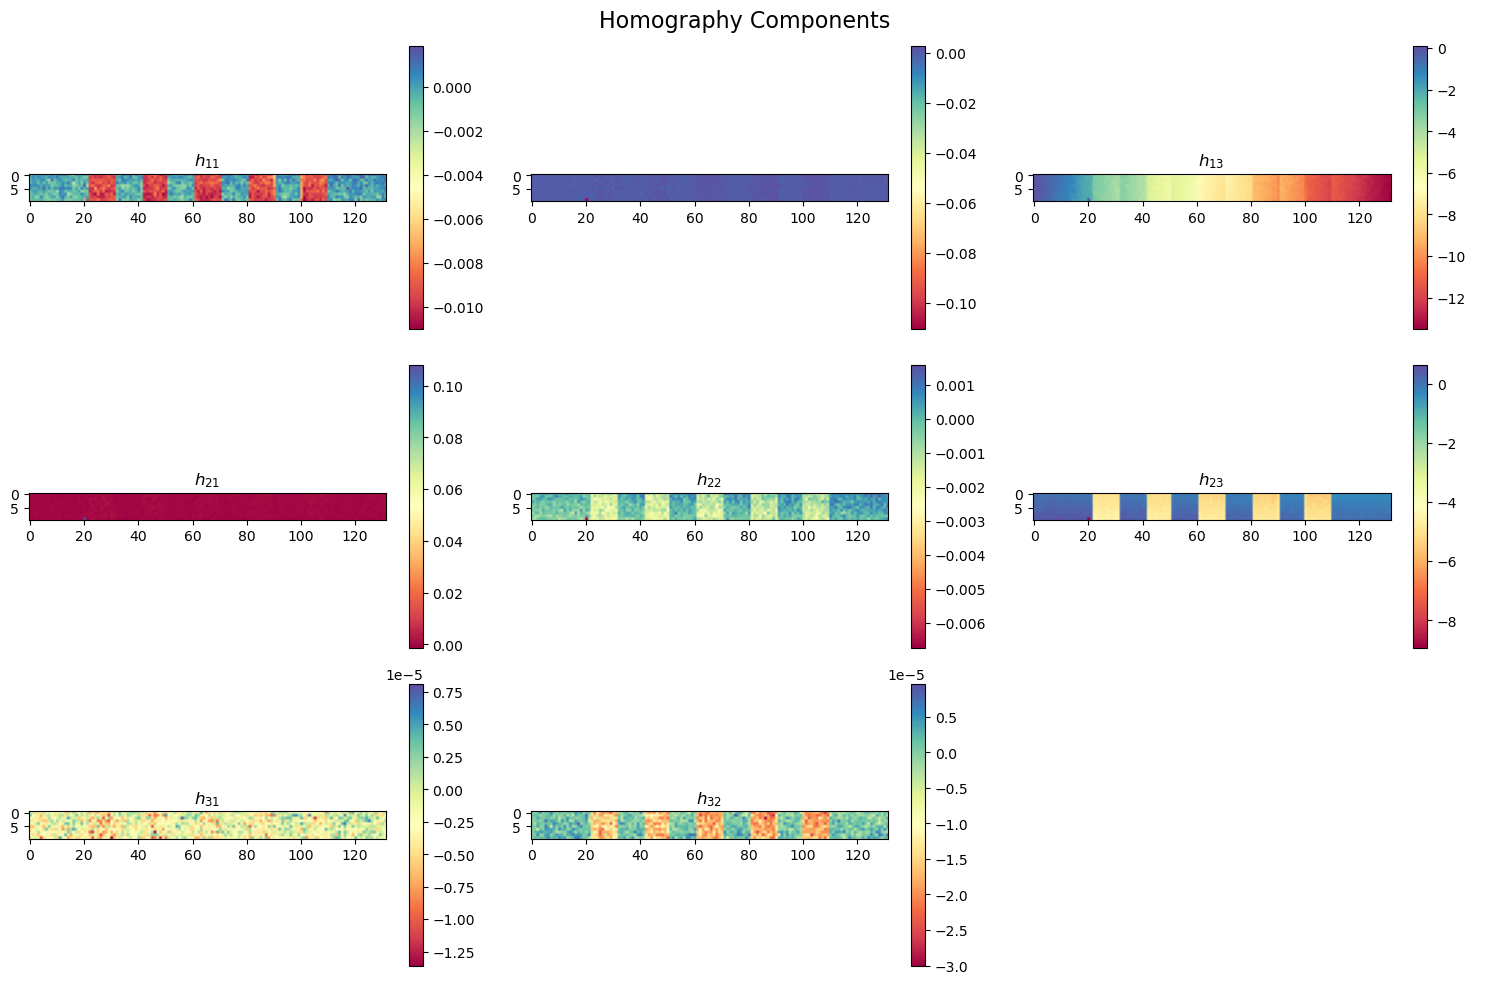

In [8]:
#plot strain components as subplots
fig, ax = plt.subplots(3, 3, figsize=(15, 10))

ax[0, 0].imshow(h11.reshape(Rows, Columns), cmap="Spectral")
cb1 = fig.colorbar(ax[0,0].imshow(h11.reshape(Rows, Columns), cmap="Spectral"), ax=ax[0,0])
#cb1.set_ticks([-5e-2, -5e-3, 0, 5e-3, 5e-2])
# mark pixel (0,0)
# ax[0, 0].plot(50, 35, 'kx', markersize=12, markeredgewidth=2)

ax[0, 0].set_title(r"$h_{11}$")

ax[0, 1].imshow(h12.reshape(Rows, Columns), cmap="Spectral")
cb2 = fig.colorbar(ax[0,1].imshow(h12.reshape(Rows, Columns), cmap="Spectral"), ax=ax[0,1])
#cb2.set_ticks([-5e-2, -5e-3, 0, 5e-3, 5e-2])
#ax[0, 1].set_title("ε12")

ax[0, 2].imshow(h13.reshape(Rows, Columns), cmap="Spectral")
cb3 = fig.colorbar(ax[0,2].imshow(h13.reshape(Rows, Columns), cmap="Spectral"), ax=ax[0,2])
#cb3.set_ticks([-5e-2, -5e-3, 0, 5e-3, 5e-2])
ax[0, 2].set_title(r"$h_{13}$")

ax[1, 0].imshow(h21.reshape(Rows, Columns), cmap="Spectral")
cb4 = fig.colorbar(ax[1,0].imshow(h21.reshape(Rows, Columns), cmap="Spectral"), ax=ax[1,0])
#cb4.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[1, 0].set_title(r"$h_{21}$")

ax[1, 1].imshow(h22.reshape(Rows, Columns), cmap="Spectral")
cb5 = fig.colorbar(ax[1,1].imshow(h22.reshape(Rows, Columns), cmap="Spectral"), ax=ax[1,1])
#cb5.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[1, 1].set_title(r"$h_{22}$")

ax[1, 2].imshow(h23.reshape(Rows, Columns), cmap="Spectral")
cb6 = fig.colorbar(ax[1,2].imshow(h23.reshape(Rows, Columns), cmap="Spectral"), ax=ax[1,2])
#cb6.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[1, 2].set_title(r"$h_{23}$")

ax[2, 0].imshow(h31.reshape(Rows, Columns), cmap="Spectral")
cb7 = fig.colorbar(ax[2,0].imshow(h31.reshape(Rows, Columns), cmap="Spectral"), ax=ax[2,0])
#cb7.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[2, 0].set_title(r"$h_{31}$")

ax[2, 1].imshow(h32.reshape(Rows, Columns), cmap="Spectral")
cb8 = fig.colorbar(ax[2,1].imshow(h32.reshape(Rows, Columns), cmap="Spectral"), ax=ax[2,1])
#cb8.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[2, 1].set_title(r"$h_{32}$")
ax[2, 2].axis("off")
#set a supertitle
fig.suptitle(f"Homography Components", fontsize=16)

plt.tight_layout()
plt.savefig(f"{foldername}/Homography_Components - DETECTOR REFERENCE FRAME.png")

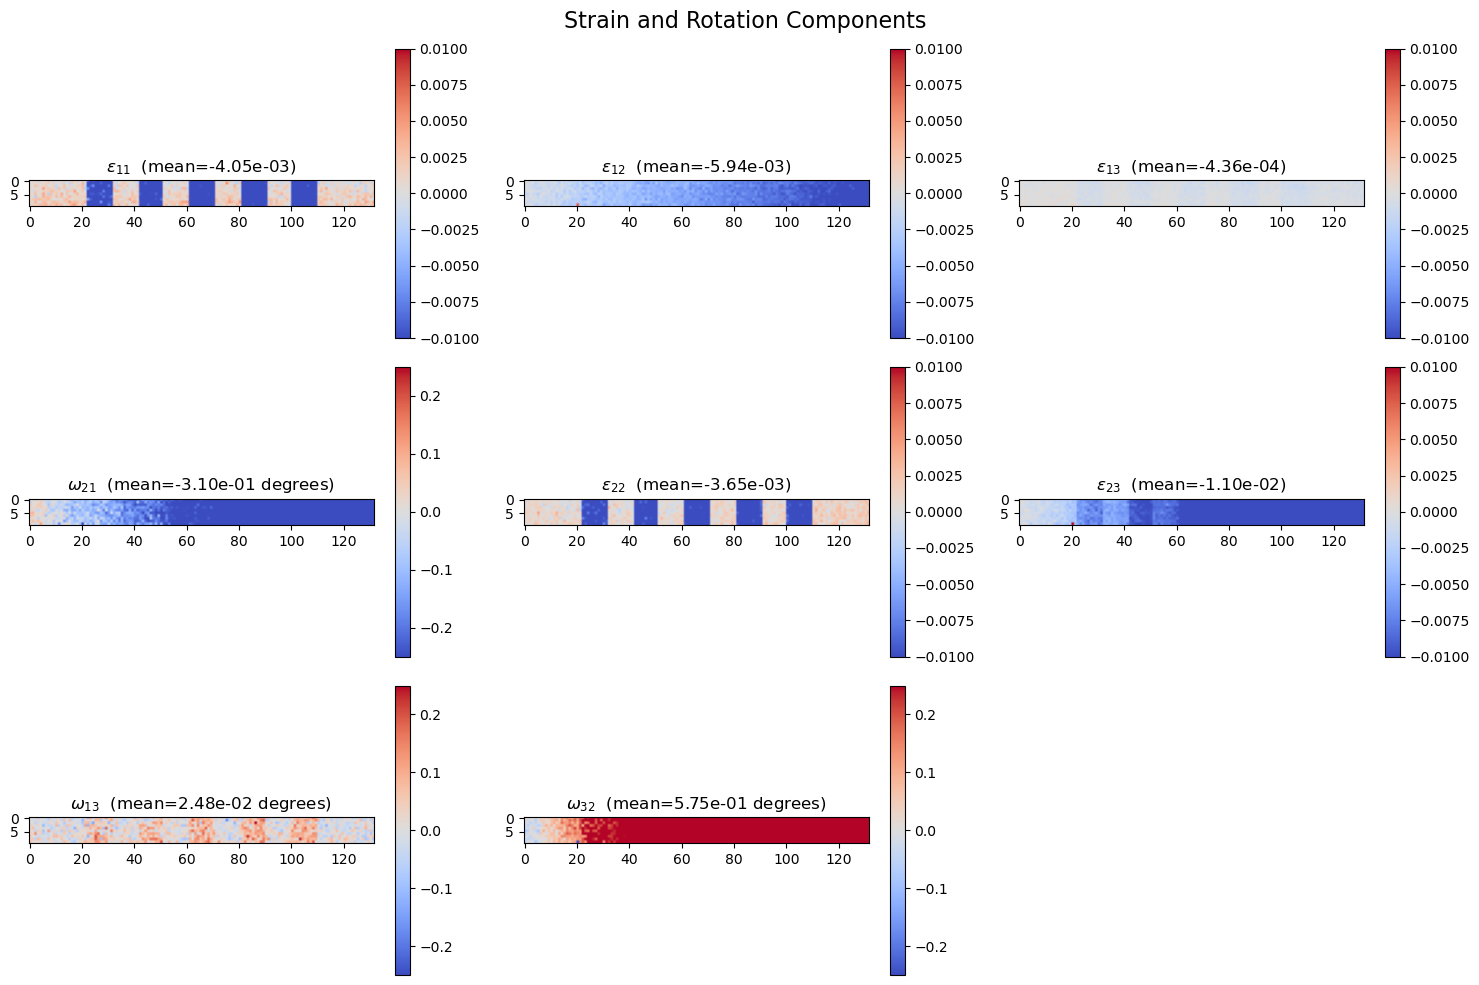

In [9]:

#plot strain components as subplots
fig, ax = plt.subplots(3, 3, figsize=(15, 10))

vmin = -1e-2
vmax = 1e-2
vmin_rot =-0.25
vmax_rot = 0.25

ax[0, 0].imshow(e11, cmap="coolwarm", vmin=vmin, vmax=vmax)
cb1 = fig.colorbar(ax[0,0].imshow(e11, cmap="coolwarm", vmin=vmin, vmax=vmax), ax=ax[0,0])
#cb1.set_ticks([-5e-2, -5e-3, 0, 5e-3, 5e-2])
# mark pixel (0,0)
# ax[0, 0].plot(50, 35, 'kx', markersize=12, markeredgewidth=2)
# ax[0, 0].set_title("ε11")
ax[0, 0].set_title(r"$ \epsilon_{11}$" + f"  (mean={e11.mean():.2e})")

ax[0, 1].imshow(e12, cmap="coolwarm", vmin=vmin, vmax=vmax)
cb2 = fig.colorbar(ax[0,1].imshow(e12, cmap="coolwarm", vmin=vmin, vmax=vmax), ax=ax[0,1])
#cb2.set_ticks([-5e-2, -5e-3, 0, 5e-3, 5e-2])
#ax[0, 1].set_title("ε12")
ax[0, 1].set_title(r"$ \epsilon_{12}$" + f"  (mean={e12.mean():.2e})")


ax[0, 2].imshow(e13, cmap="coolwarm", vmin=vmin, vmax=vmax)
cb3 = fig.colorbar(ax[0,2].imshow(e13, cmap="coolwarm", vmin=vmin, vmax=vmax), ax=ax[0,2])
#cb3.set_ticks([-5e-2, -5e-3, 0, 5e-3, 5e-2])
ax[0, 2].set_title(r"$ \epsilon_{13}$" + f"  (mean={e13.mean():.2e})")

ax[1, 0].imshow(w21, cmap="coolwarm", vmin=vmin, vmax=vmax)
cb4 = fig.colorbar(ax[1,0].imshow(w21, cmap="coolwarm", vmin=vmin_rot, vmax=vmax_rot), ax=ax[1,0])
#cb4.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[1, 0].set_title(r"$ \omega_{21}$" + f"  (mean={w21.mean():.2e} degrees)")

ax[1, 1].imshow(e22, cmap="coolwarm", vmin=vmin, vmax=vmax)
cb5 = fig.colorbar(ax[1,1].imshow(e22, cmap="coolwarm", vmin=vmin, vmax=vmax), ax=ax[1,1])
#cb5.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[1, 1].set_title(r"$ \epsilon_{22}$" + f"  (mean={e22.mean():.2e})")

ax[1, 2].imshow(e23, cmap="coolwarm", vmin=vmin, vmax=vmax)
cb6 = fig.colorbar(ax[1,2].imshow(e23, cmap="coolwarm", vmin=vmin, vmax=vmax), ax=ax[1,2])
#cb6.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[1, 2].set_title(r"$ \epsilon_{23}$" + f"  (mean={e23.mean():.2e})")

ax[2, 0].imshow(w13, cmap="coolwarm", vmin=vmin, vmax=vmax)
cb7 = fig.colorbar(ax[2,0].imshow(w13, cmap="coolwarm", vmin=vmin_rot, vmax=vmax_rot), ax=ax[2,0])
#cb7.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[2, 0].set_title(r"$ \omega_{13}$" + f"  (mean={w13.mean():.2e} degrees)")

ax[2, 1].imshow(w32, cmap="coolwarm", vmin=vmin, vmax=vmax)
cb8 = fig.colorbar(ax[2,1].imshow(w32, cmap="coolwarm", vmin=vmin_rot, vmax=vmax_rot), ax=ax[2,1])
#cb8.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[2, 1].set_title(r"$ \omega_{32}$" + f"  (mean={w32.mean():.2e} degrees)")
ax[2, 2].axis("off")
#set a supertitle
fig.suptitle(f"Strain and Rotation Components", fontsize=16)

plt.tight_layout()
plt.savefig(f"{foldername}/Strain_and_Rotation_Calculated - DETECTOR REFERENCE FRAME.png")

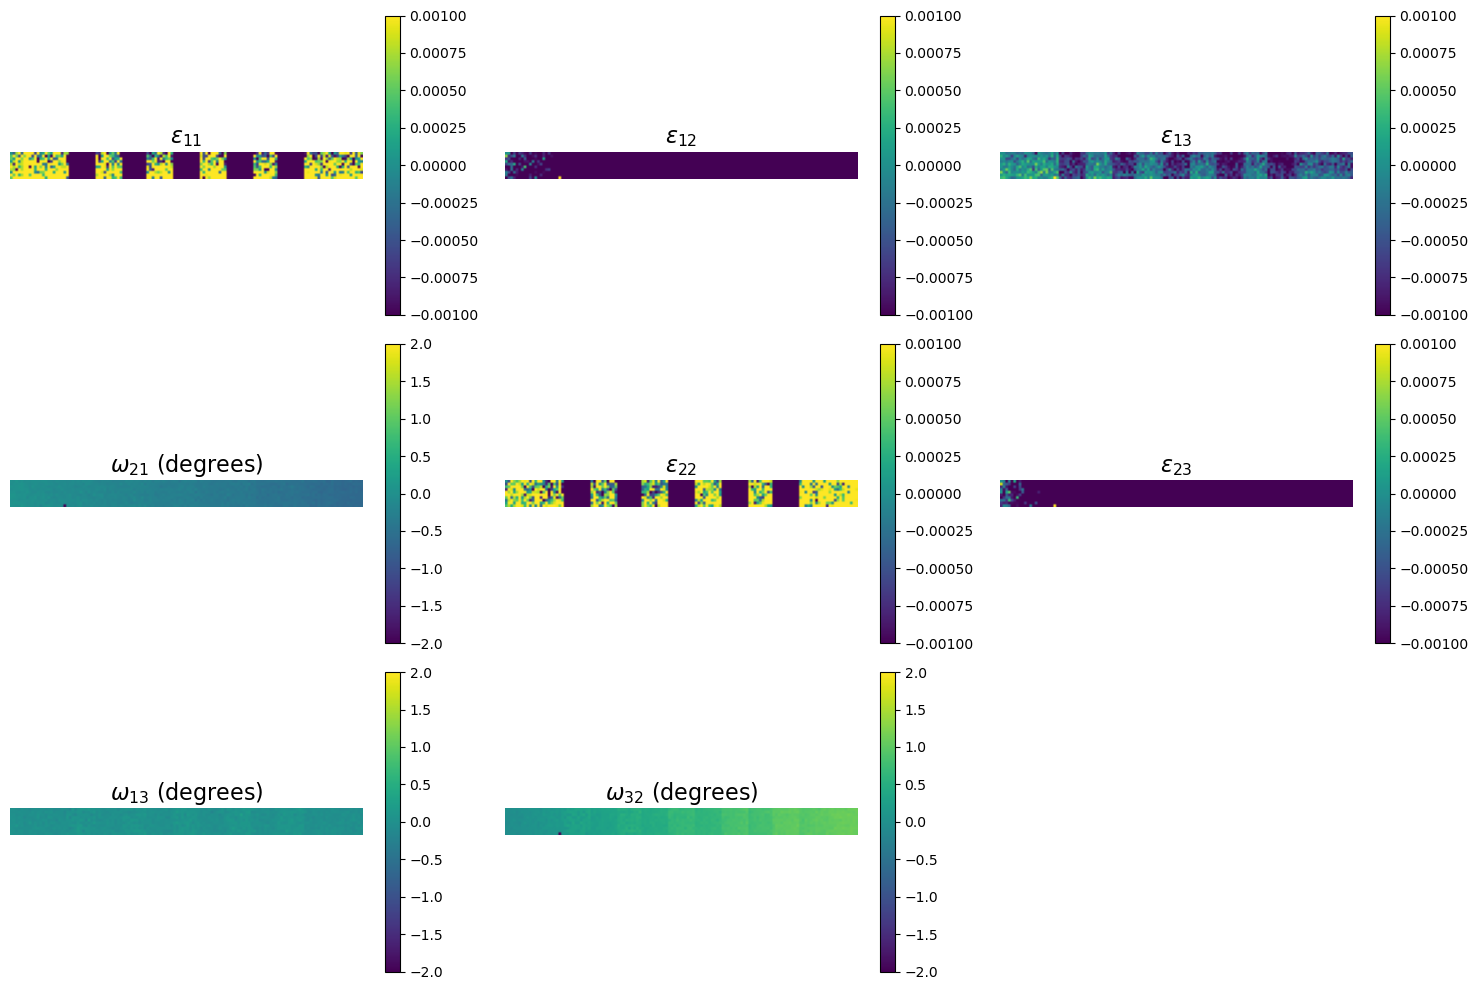

In [10]:

#plot strain components as subplots
fig, ax = plt.subplots(3, 3, figsize=(15, 10))

vmin = -1e-3
vmax = 1e-3
vmin_rot =-2.0
vmax_rot = 2.0

ax[0, 0].imshow(e11, cmap="viridis", vmin=vmin, vmax=vmax)
cb1 = fig.colorbar(ax[0,0].imshow(e11, cmap="viridis", vmin=vmin, vmax=vmax), ax=ax[0,0])
#cb1.set_ticks([-5e-2, -1e-2, 0, 1e-2, 5e-2])
# mark pixel (0,0)
#ax[0, 0].plot(50, 35, 'kx', markersize=12, markeredgewidth=2)
ax[0, 0].set_title(r"$ \epsilon_{11}$", fontsize=16)
ax[0,0].axis('off')

ax[0, 1].imshow(e12, cmap="viridis", vmin=vmin, vmax=vmax)
cb2 = fig.colorbar(ax[0,1].imshow(e12, cmap="viridis", vmin=vmin, vmax=vmax), ax=ax[0,1])
#cb2.set_ticks([-5e-2, -1e-2, 0, 1e-2, 5e-2])
ax[0, 1].set_title(r"$ \epsilon_{12}$", fontsize=16)
ax[0,1].axis('off')

ax[0, 2].imshow(e13, cmap="viridis", vmin=vmin, vmax=vmax)
cb3 = fig.colorbar(ax[0,2].imshow(e13, cmap="viridis", vmin=vmin, vmax=vmax), ax=ax[0,2])
#cb3.set_ticks([-5e-2, -1e-2, 0, 1e-2, 5e-2])
ax[0, 2].set_title(r"$ \epsilon_{13}$", fontsize=16)
ax[0,2].axis('off')


ax[1, 0].imshow(w21, cmap="viridis", vmin=vmin_rot, vmax=vmax_rot)
cb4 = fig.colorbar(ax[1,0].imshow(w21, cmap="viridis", vmin=vmin_rot, vmax=vmax_rot), ax=ax[1,0])
#cb4.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[1, 0].set_title(r"$ \omega_{21}$ (degrees)", fontsize=16)
ax[1,0].axis('off')

ax[1, 1].imshow(e22, cmap="viridis", vmin=vmin, vmax=vmax)
cb5 = fig.colorbar(ax[1,1].imshow(e22, cmap="viridis", vmin=vmin, vmax=vmax), ax=ax[1,1])
#cb5.set_ticks([-5e-2, -1e-2, 0, 1e-2, 5e-2])
ax[1, 1].set_title(r"$ \epsilon_{22}$", fontsize=16)
ax[1,1].axis('off')

ax[1, 2].imshow(e23, cmap="viridis", vmin=vmin, vmax=vmax)
cb6 = fig.colorbar(ax[1,2].imshow(e23, cmap="viridis", vmin=vmin, vmax=vmax), ax=ax[1,2])
#cb6.set_ticks([-5e-2, -1e-2, 0, 1e-2, 5e-2])
ax[1, 2].set_title(r"$ \epsilon_{23}$", fontsize=16)
ax[1, 2].axis('off')

ax[2, 0].imshow(w13, cmap="viridis", vmin=vmin_rot, vmax=vmax_rot)
cb7 = fig.colorbar(ax[2,0].imshow(w13, cmap="viridis", vmin=vmin_rot, vmax=vmax_rot), ax=ax[2,0])
#cb7.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[2, 0].set_title(r"$ \omega_{13}$ (degrees)", fontsize=16)
ax[2, 0].axis('off')

ax[2, 1].imshow(w32, cmap="viridis", vmin=vmin_rot, vmax=vmax_rot)
cb8 = fig.colorbar(ax[2,1].imshow(w32, cmap="viridis", vmin=vmin_rot, vmax=vmax_rot), ax=ax[2,1])
#cb8.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[2, 1].set_title(r"$ \omega_{32}$ (degrees)", fontsize=16)
ax[2, 1].axis('off')
ax[2, 2].axis("off")
#set a supertitle
#fig.suptitle(f"Strain and Rotation Components", fontsize=16)

plt.tight_layout()
plt.savefig(f"{foldername}/Strain_and_Rotation_Calculated - viridis.png")

In [11]:
#also save each subplot individually
components = {
    "e11": e11,
    "e12": e12, 
    "e13": e13,
    "e22": e22,
    "e23": e23,
    "e33": e33,
    "w13": w13,
    "w21": w21,
    "w32": w32
}

for name, data in components.items():
    plt.figure(figsize=(6,5))
    plt.imshow(data, cmap="viridis", vmin=vmin, vmax=vmax)
    cb = plt.colorbar()
    #cb.set_ticks([-5e-2, -2.5e-2, 0, 2.5e-2, 5e-2])
    plt.title(f"{name} Component")
    plt.savefig(f"{foldername}/{name}_Calculated - DETECTOR REFERENCE FRAME.png")
    plt.close()

# Traction-Free Surface BC → Absolute Strain and Lattice Tetragonality

HR-EBSD is insensitive to hydrostatic dilation, so `F2strain` returns *deviatoric* strains where `e33 = 0` by construction.  
The traction-free surface boundary condition (`σ33 = 0`) lets us recover the true out-of-plane strain, and from that the absolute in-plane strains and lattice tetragonality.

For a cubic material the condition `σ33 = 0` gives:

```
e33 = -C12 * (ê11 + ê22) / (C11 + 2·C12)
```

where ê11, ê22 are the deviatoric strains already computed above.  
Absolute strains then follow as `e11_abs = ê11 + e33`, `e22_abs = ê22 + e33`.

**Note:** this cell must be run with `samp_frame = True` so that index-3 is the surface normal.

In [12]:
# ------ Silicon elastic constants (crystal frame, Voigt notation) ------
# Si: C11=165.7, C12=63.9, C44=79.6  (GPa)  [Madelung 1982]
C11_Si = 165.7e9  # Pa
C12_Si =  63.9e9
C44_Si =  79.6e9

C_crystal = utilities.get_stiffness_tensor(C11_Si, C12_Si, C44_Si, structure="cubic")
print("C_crystal (GPa):")
print(np.round(C_crystal / 1e9, 2))

# ------ Per-pattern quaternion: reference orientation ⊗ local rotation from F ------
# The IC-GN deformation gradient F carries the local lattice rotation at each
# scan position relative to the reference pattern.  We polar-decompose F = R_local @ U
# and compose R_local with the base orientation so that C_rot reflects the true
# per-pattern crystal orientation in the sample frame.
#
# Base orientation source:
#   ang_file is None  → single euler_angles_deg tiled to all patterns
#   ang_file set      → per-pattern Euler angles read from the .ang file
import rotations
from scipy.linalg import polar as polar_decomp

N = Rows * Columns

if ang_file is not None:
    ang_data = utilities.read_ang(ang_file, tuple(patshape))
    # eulers shape: (Rows, Columns, 3) in radians — flatten to (N, 3)
    base_quats = ang_data.quats.reshape(N, 4)   # already quaternions
    print(f"Loaded per-pattern orientations from {ang_file}")
else:
    euler_angles_rad = np.deg2rad(euler_angles_deg)
    single_quat = rotations.eu2qu(euler_angles_rad)
    base_quats = np.tile(single_quat, (N, 1))   # (N, 4)
    print(f"Using single Euler angle {euler_angles_deg} deg for all {N} patterns")

quats_flat = np.empty((N, 4), dtype=np.float64)
for idx in range(N):
    R_base     = rotations.qu2om(base_quats[idx])  # (3, 3) base orientation at this point
    R_local, _ = polar_decomp(F[idx])              # rotation part of F
    R_total    = R_base @ R_local                   # compose: base then local
    quats_flat[idx] = rotations.om2qu(R_total)

print(f"Per-pattern quats computed for {N} patterns ({Rows} rows x {Columns} cols)")

# ------ Rotate C to sample frame for each pattern ------
# utilities.rotate_stiffness_to_sample_frame returns shape (N, 6, 6)
C_rot = utilities.rotate_stiffness_to_sample_frame(C_crystal, quats_flat)  # (N, 6, 6)
print("C_rot shape:", C_rot.shape)
print("Mean C_rot[0,0] (C11 equivalent, GPa):", np.round(C_rot[:, 0, 0].mean() / 1e9, 2))

# ------ Traction-free BC: solve for e33_abs using per-pattern rotated C ------
# Voigt index mapping: 0=11, 1=22, 2=33, 3=23, 4=13, 5=12
# sigma_33 = C31*(e11_dev+e33) + C32*(e22_dev+e33) + C33*e33
#          + 2*C34*e23 + 2*C35*e13 + 2*C36*e12 = 0
# => e33 = -(C31*e11_dev + C32*e22_dev + 2*C34*e23 + 2*C35*e13 + 2*C36*e12)
#          / (C31 + C32 + C33)

if not samp_frame:
    raise RuntimeError("Traction-free BC requires samp_frame=True so that axis-3 is the surface normal.")

# Flatten the 2D strain maps to 1D for vectorised calculation
e11_flat = e11.ravel()   # deviatoric
e22_flat = e22.ravel()
e12_flat = e12.ravel()
e13_flat = e13.ravel()
e23_flat = e23.ravel()

C31 = C_rot[:, 2, 0]   # (N,)
C32 = C_rot[:, 2, 1]
C33 = C_rot[:, 2, 2]
C34 = C_rot[:, 2, 3]
C35 = C_rot[:, 2, 4]
C36 = C_rot[:, 2, 5]

numerator   = C31*e11_flat + C32*e22_flat + 2*C34*e23_flat + 2*C35*e13_flat + 2*C36*e12_flat
denominator = C31 + C32 + C33

e33_abs_flat = -numerator / denominator
e11_abs_flat = e11_flat + e33_abs_flat
e22_abs_flat = e22_flat + e33_abs_flat

# Reshape back to (Rows, Columns)
e33_abs = e33_abs_flat.reshape(Rows, Columns)
e11_abs = e11_abs_flat.reshape(Rows, Columns)
e22_abs = e22_abs_flat.reshape(Rows, Columns)

# Tetragonality c/a
e_in_plane = 0.5 * (e11_abs + e22_abs)
tetragonality_ratio = (1 + e33_abs) / (1 + e_in_plane)

print(f"Mean e33_abs : {e33_abs.mean():.4e}")
print(f"Mean e11_abs : {e11_abs.mean():.4e}")
print(f"Mean e22_abs : {e22_abs.mean():.4e}")
print(f"Mean c/a     : {tetragonality_ratio.mean():.6f}")


C_crystal (GPa):
[[165.7  63.9  63.9   0.    0.    0. ]
 [ 63.9 165.7  63.9   0.    0.    0. ]
 [ 63.9  63.9 165.7   0.    0.    0. ]
 [  0.    0.    0.   79.6   0.    0. ]
 [  0.    0.    0.    0.   79.6   0. ]
 [  0.    0.    0.    0.    0.   79.6]]
X-step size: 2.6
Pattern center (xstar, ystar, zstar): (0.6878, 0.8978, 1.0691)
FIELD COUNT: 11
VALUES COUNT: 11
Loaded per-pattern orientations from /Users/crestiennedechaine/OriginalData/Si_Ge_Dataset/DI_largerRegion/SiGe_largerRegion_selectedArea_20260322_512x512.ang
Per-pattern quats computed for 1320 patterns (10 rows x 132 cols)
C_rot shape: (1320, 6, 6)
Mean C_rot[0,0] (C11 equivalent, GPa): 168.35
Mean e33_abs : 1.2938e-03
Mean e11_abs : -2.7537e-03
Mean e22_abs : -2.3559e-03
Mean c/a     : 1.003886


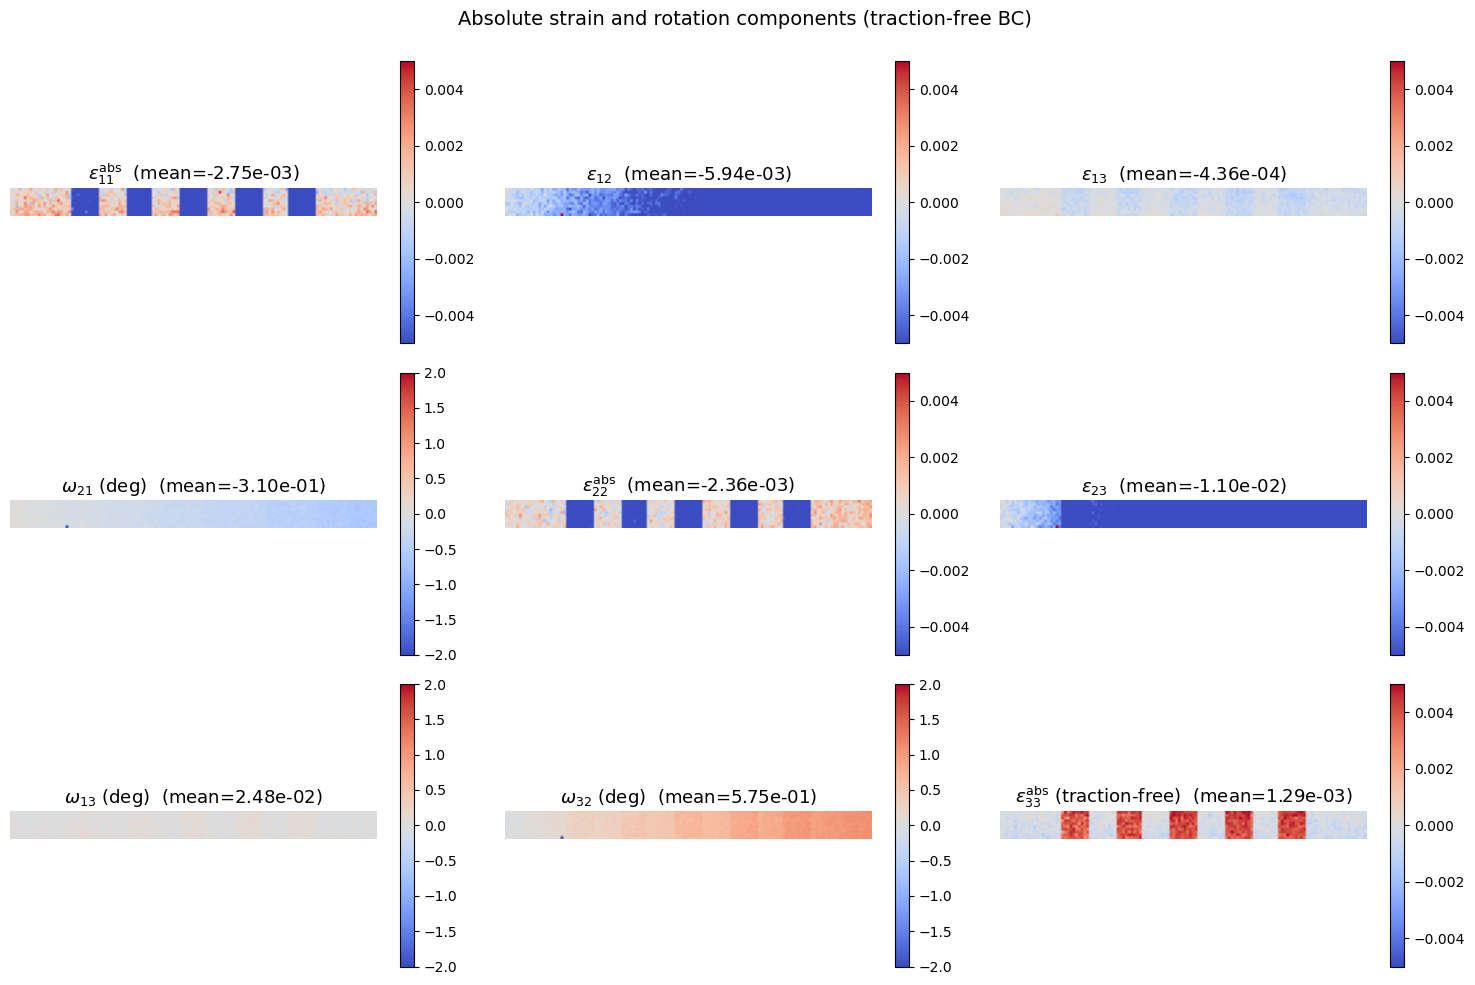

Saved /Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/results/SiGe/SiGe_PCcorrectionApplied_Apr8//Absolute_strain_grid.png


In [13]:
# ------ Plot all strain + rotation components with absolute e11, e22, e33 ------
vmin_s   = -5e-3
vmax_s   =  5e-3
vmin_rot = -2.0
vmax_rot =  2.0

fig, ax = plt.subplots(3, 3, figsize=(15, 10))

ax[0, 0].imshow(e11_abs, cmap="coolwarm", vmin=vmin_s, vmax=vmax_s)
fig.colorbar(ax[0, 0].imshow(e11_abs, cmap="coolwarm", vmin=vmin_s, vmax=vmax_s), ax=ax[0, 0])
ax[0, 0].set_title(r"$\epsilon_{11}^{\mathrm{abs}}$" + f"  (mean={e11_abs.mean():.2e})", fontsize=13)
ax[0, 0].axis("off")

ax[0, 1].imshow(e12, cmap="coolwarm", vmin=vmin_s, vmax=vmax_s)
fig.colorbar(ax[0, 1].imshow(e12, cmap="coolwarm", vmin=vmin_s, vmax=vmax_s), ax=ax[0, 1])
ax[0, 1].set_title(r"$\epsilon_{12}$" + f"  (mean={e12.mean():.2e})", fontsize=13)
ax[0, 1].axis("off")

ax[0, 2].imshow(e13, cmap="coolwarm", vmin=vmin_s, vmax=vmax_s)
fig.colorbar(ax[0, 2].imshow(e13, cmap="coolwarm", vmin=vmin_s, vmax=vmax_s), ax=ax[0, 2])
ax[0, 2].set_title(r"$\epsilon_{13}$" + f"  (mean={e13.mean():.2e})", fontsize=13)
ax[0, 2].axis("off")

ax[1, 0].imshow(w21, cmap="coolwarm", vmin=vmin_rot, vmax=vmax_rot)
fig.colorbar(ax[1, 0].imshow(w21, cmap="coolwarm", vmin=vmin_rot, vmax=vmax_rot), ax=ax[1, 0])
ax[1, 0].set_title(r"$\omega_{21}$ (deg)" + f"  (mean={w21.mean():.2e})", fontsize=13)
ax[1, 0].axis("off")

ax[1, 1].imshow(e22_abs, cmap="coolwarm", vmin=vmin_s, vmax=vmax_s)
fig.colorbar(ax[1, 1].imshow(e22_abs, cmap="coolwarm", vmin=vmin_s, vmax=vmax_s), ax=ax[1, 1])
ax[1, 1].set_title(r"$\epsilon_{22}^{\mathrm{abs}}$" + f"  (mean={e22_abs.mean():.2e})", fontsize=13)
ax[1, 1].axis("off")

ax[1, 2].imshow(e23, cmap="coolwarm", vmin=vmin_s, vmax=vmax_s)
fig.colorbar(ax[1, 2].imshow(e23, cmap="coolwarm", vmin=vmin_s, vmax=vmax_s), ax=ax[1, 2])
ax[1, 2].set_title(r"$\epsilon_{23}$" + f"  (mean={e23.mean():.2e})", fontsize=13)
ax[1, 2].axis("off")

ax[2, 0].imshow(w13, cmap="coolwarm", vmin=vmin_rot, vmax=vmax_rot)
fig.colorbar(ax[2, 0].imshow(w13, cmap="coolwarm", vmin=vmin_rot, vmax=vmax_rot), ax=ax[2, 0])
ax[2, 0].set_title(r"$\omega_{13}$ (deg)" + f"  (mean={w13.mean():.2e})", fontsize=13)
ax[2, 0].axis("off")

ax[2, 1].imshow(w32, cmap="coolwarm", vmin=vmin_rot, vmax=vmax_rot)
fig.colorbar(ax[2, 1].imshow(w32, cmap="coolwarm", vmin=vmin_rot, vmax=vmax_rot), ax=ax[2, 1])
ax[2, 1].set_title(r"$\omega_{32}$ (deg)" + f"  (mean={w32.mean():.2e})", fontsize=13)
ax[2, 1].axis("off")

ax[2, 2].imshow(e33_abs, cmap="coolwarm", vmin=vmin_s, vmax=vmax_s)
fig.colorbar(ax[2, 2].imshow(e33_abs, cmap="coolwarm", vmin=vmin_s, vmax=vmax_s), ax=ax[2, 2])
ax[2, 2].set_title(r"$\epsilon_{33}^{\mathrm{abs}}$ (traction-free)" + f"  (mean={e33_abs.mean():.2e})", fontsize=13)
ax[2, 2].axis("off")

fig.suptitle(
    "Absolute strain and rotation components (traction-free BC)\n",
    fontsize=14
)
plt.tight_layout()
save_path = f"{foldername}/Absolute_strain_grid.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {save_path}")

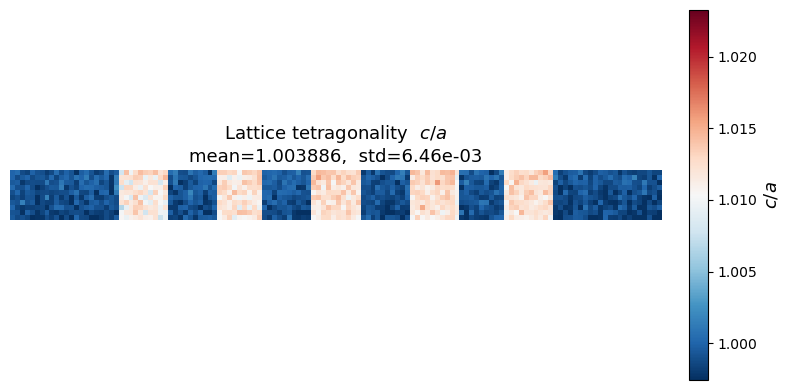

Saved /Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/results/SiGe/SiGe_PCcorrectionApplied_Apr8//Tetragonality_ca.png
Saved .npy files: e11_abs, e22_abs, e33_abs, tetragonality_ca


In [14]:
# ------ Standalone tetragonality map ------
ca_mean = tetragonality_ratio.mean()
ca_std  = tetragonality_ratio.std()
vmin_ca = ca_mean - 1 * ca_std
vmax_ca = ca_mean + 3 * ca_std

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
im = ax.imshow(tetragonality_ratio, cmap="RdBu_r", vmin=vmin_ca, vmax=vmax_ca)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cb.set_label(r"$c/a$", fontsize=13)
ax.set_title(
    r"Lattice tetragonality  $c/a$" + f"\nmean={ca_mean:.6f},  std={ca_std:.2e}",
    fontsize=13,
)
ax.axis("off")
plt.tight_layout()
save_path = f"{foldername}/Tetragonality_ca.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {save_path}")


print("Saved .npy files: e11_abs, e22_abs, e33_abs, tetragonality_ca")

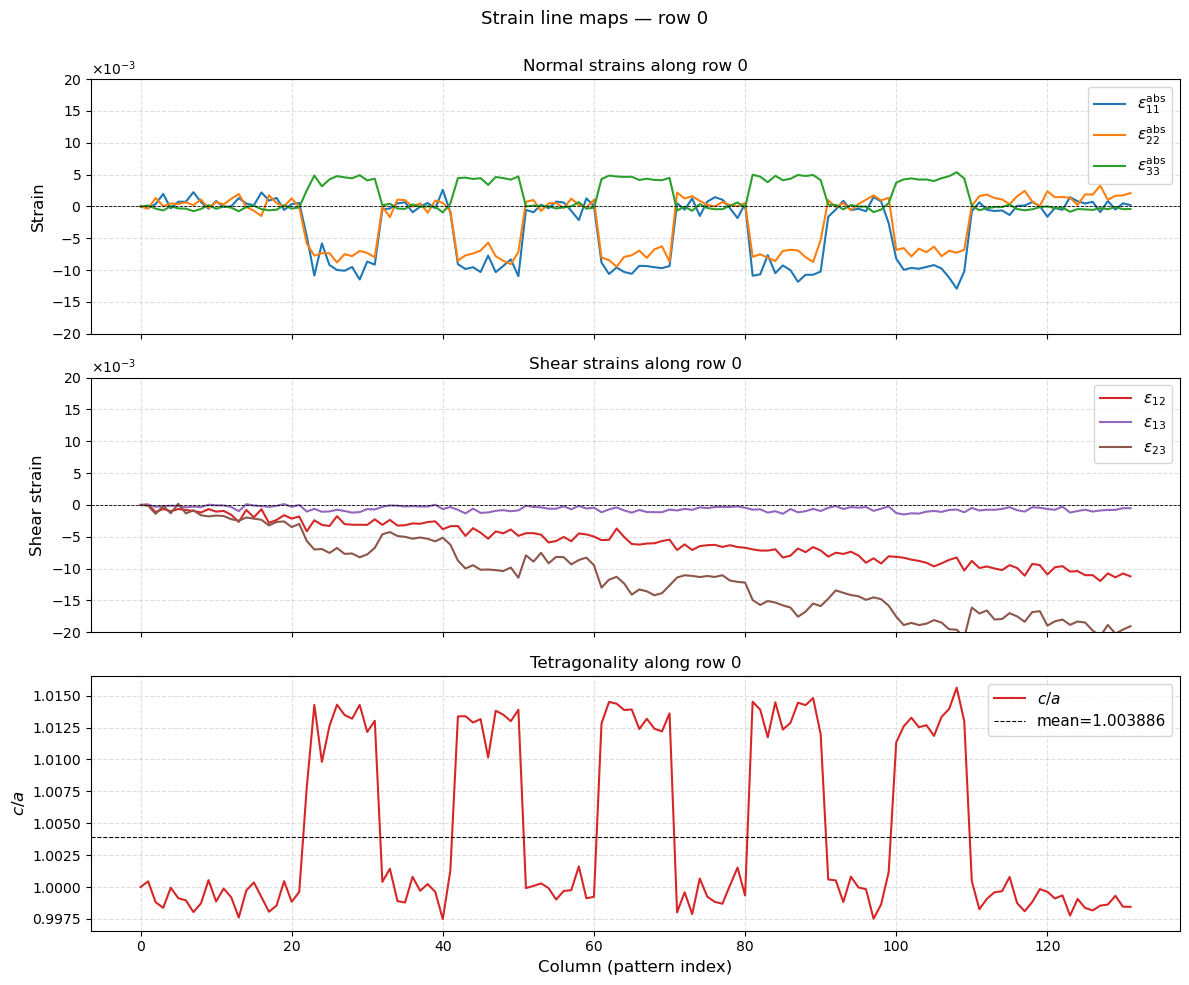

Saved /Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/results/SiGe/SiGe_PCcorrectionApplied_Apr8//Strain_linemap_row0.png


In [15]:
# ------ First-row line maps: all strain components + tetragonality ------
# Plots the values along row index `linemap_row` as a function of column position.
linemap_row = 0   # change to plot a different row

import matplotlib.ticker as ticker

def _strain_formatter(ax):
    fmt = ticker.ScalarFormatter(useMathText=True)
    fmt.set_scientific(True)
    fmt.set_powerlimits((-3, -3))
    ax.yaxis.set_major_formatter(fmt)

x_pos = np.arange(Columns)

strain_lines = [
    (e11_abs[linemap_row, :], r"$\epsilon_{11}^{\mathrm{abs}}$", "tab:blue"),
    (e22_abs[linemap_row, :], r"$\epsilon_{22}^{\mathrm{abs}}$", "tab:orange"),
    (e33_abs[linemap_row, :], r"$\epsilon_{33}^{\mathrm{abs}}$", "tab:green"),
    (e12[linemap_row, :],     r"$\epsilon_{12}$",                "tab:red"),
    (e13[linemap_row, :],     r"$\epsilon_{13}$",                "tab:purple"),
    (e23[linemap_row, :],     r"$\epsilon_{23}$",                "tab:brown"),
]
rot_lines = [
    (w13[linemap_row, :], r"$\omega_{13}$ (deg)", "tab:blue"),
    (w21[linemap_row, :], r"$\omega_{21}$ (deg)", "tab:orange"),
    (w32[linemap_row, :], r"$\omega_{32}$ (deg)", "tab:green"),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Panel 1: normal strains
ax0 = axes[0]
for data, label, color in strain_lines[:3]:
    ax0.plot(x_pos, data, label=label, linewidth=1.5, color=color)
ax0.set_ylim(-20e-3, 20e-3)
_strain_formatter(ax0)
ax0.set_ylabel("Strain", fontsize=12)
ax0.set_title(f"Normal strains along row {linemap_row}", fontsize=12)
ax0.axhline(0, color="k", linewidth=0.6, linestyle="--")
ax0.legend(fontsize=11, loc="upper right")
ax0.grid(True, linestyle="--", alpha=0.4)

# Panel 2: shear strains
ax1 = axes[1]
for data, label, color in strain_lines[3:]:
    ax1.plot(x_pos, data, label=label, linewidth=1.5, color=color)
ax1.set_ylim(-20e-3, 20e-3)
_strain_formatter(ax1)
ax1.set_ylabel("Shear strain", fontsize=12)
ax1.set_title(f"Shear strains along row {linemap_row}", fontsize=12)
ax1.axhline(0, color="k", linewidth=0.6, linestyle="--")
ax1.legend(fontsize=11, loc="upper right")
ax1.grid(True, linestyle="--", alpha=0.4)

# Panel 3: tetragonality
ax2 = axes[2]
ax2.plot(x_pos, tetragonality_ratio[linemap_row, :], color="tab:red", linewidth=1.5, label=r"$c/a$")
ax2.axhline(tetragonality_ratio.mean(), color="k", linewidth=0.8, linestyle="--", label=f"mean={tetragonality_ratio.mean():.6f}")
ax2.set_ylabel(r"$c/a$", fontsize=12)
ax2.set_xlabel("Column (pattern index)", fontsize=12)
ax2.set_title(f"Tetragonality along row {linemap_row}", fontsize=12)
ax2.legend(fontsize=11, loc="upper right")
ax2.grid(True, linestyle="--", alpha=0.4)

plt.suptitle(
    f"Strain line maps — row {linemap_row}\n",
    fontsize=13,
)
plt.tight_layout()
save_path = f"{foldername}/Strain_linemap_row{linemap_row}.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {save_path}")